# DATA620 Week Ten - Document Classification

**Author:** Sabina Baraili  
**Course:** DATA620 Web Analytics

This notebook completes the Week Ten assignment on document classification.
I use the UCI Spambase dataset as the labeled training corpus and treat a held-out
test split as new, unseen documents. The goal is to predict whether each e-mail is
spam (`1`) or ham (`0`).


## Requirement Alignment

The assignment prompt says I may either:

1. Use the provided dataset to predict the class of new documents.
2. Take the more adventurous route and assemble a different labeled corpus.

In this notebook I follow the first option directly, using the UCI Spambase dataset.
To make the "new documents" requirement concrete, I hold out part of the labeled data
before training. Those withheld records are treated as unseen e-mails, and the final
model predicts their class only after training is complete.


## Overview

The UCI Spambase dataset does not include raw e-mail text. Instead, each e-mail is
already represented by text-derived features such as word frequencies, special-character
frequencies, and capitalization patterns. That still fits the assignment well because
the task is document classification: learn from labeled documents, then classify unseen
ones.

I also kept the notebook style close to my earlier assignments by organizing the work
into short sections with explanation, code, evaluation, and a final interpretation.


## 1. Imports and Setup

I use `pandas` and `numpy` for data work, `matplotlib` for a few visual checks, and
`scikit-learn` to train and evaluate classification models.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:0.3f}")
RANDOM_STATE = 620


## 2. Load the Spambase Data from UCI

I fetch the dataset directly from the UCI repository, following the workflow provided
in the assignment notes. This makes the data source explicit and also lets me inspect
the repository metadata and variable descriptions before modeling.


In [2]:
spambase = fetch_ucirepo(id=94)

X = spambase.data.features.copy()
y = spambase.data.targets.copy()

if isinstance(y, pd.DataFrame):
    y = y.iloc[:, 0]

spam_df = X.copy()
spam_df["spam"] = y.astype(int)
spam_df.head()


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,word_freq_receive,word_freq_will,word_freq_people,word_freq_report,word_freq_addresses,word_freq_free,word_freq_business,word_freq_email,word_freq_you,word_freq_credit,word_freq_your,word_freq_font,word_freq_000,word_freq_money,word_freq_hp,word_freq_hpl,word_freq_george,word_freq_650,word_freq_lab,word_freq_labs,word_freq_telnet,word_freq_857,word_freq_data,word_freq_415,word_freq_85,word_freq_technology,word_freq_1999,word_freq_parts,word_freq_pm,word_freq_direct,word_freq_cs,word_freq_meeting,word_freq_original,word_freq_project,word_freq_re,word_freq_edu,word_freq_table,word_freq_conference,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.000,0.640,0.640,0.000,0.320,0.000,0.000,0.000,0.000,0.000,0.000,0.640,0.000,0.000,0.000,0.320,0.000,1.290,1.930,0.000,0.960,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.778,0.000,0.000,3.756,61,278,1
1,0.210,0.280,0.500,0.000,0.140,0.280,0.210,0.070,0.000,0.940,0.210,0.790,0.650,0.210,0.140,0.140,0.070,0.280,3.470,0.000,1.590,0.000,0.430,0.430,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.070,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.132,0.000,0.372,0.180,0.048,5.114,101,1028,1
2,0.060,0.000,0.710,0.000,1.230,0.190,0.190,0.120,0.640,0.250,0.380,0.450,0.120,0.000,1.750,0.060,0.060,1.030,1.360,0.320,0.510,0.000,1.160,0.060,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.060,0.000,0.000,0.120,0.000,0.060,0.060,0.000,0.000,0.010,0.143,0.000,0.276,0.184,0.010,9.821,485,2259,1
3,0.000,0.000,0.000,0.000,0.630,0.000,0.310,0.630,0.310,0.630,0.310,0.310,0.310,0.000,0.000,0.310,0.000,0.000,3.180,0.000,0.310,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.137,0.000,0.137,0.000,0.000,3.537,40,191,1
4,0.000,0.000,0.000,0.000,0.630,0.000,0.310,0.630,0.310,0.630,0.310,0.310,0.310,0.000,0.000,0.310,0.000,0.000,3.180,0.000,0.310,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.135,0.000,0.135,0.000,0.000,3.537,40,191,1


In [3]:
print(spambase.metadata)


{'uci_id': 94, 'name': 'Spambase', 'repository_url': 'https://archive.ics.uci.edu/dataset/94/spambase', 'data_url': 'https://archive.ics.uci.edu/static/public/94/data.csv', 'abstract': 'Classifying Email as Spam or Non-Spam', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 4601, 'num_features': 57, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1999, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C53G6X', 'creators': ['Mark Hopkins', 'Erik Reeber', 'George Forman', 'Jaap Suermondt'], 'intro_paper': None, 'additional_info': {'summary': 'The "spam" concept is diverse: advertisements for products/web sites, make money fast schemes, chain letters, pornography...\n\nThe classification task for this dataset is to determine whether a given email is spam or not.\n\t\nOur collecti

In [4]:
spambase.variables


,name,role,type,demographic,description,units,missing_values
0,word_freq_make,Feature,Continuous,None,NaN,None,no
1,word_freq_address,Feature,Continuous,None,NaN,None,no
2,word_freq_all,Feature,Continuous,None,NaN,None,no
3,word_freq_3d,Feature,Continuous,None,NaN,None,no
4,word_freq_our,Feature,Continuous,None,NaN,None,no
5,word_freq_over,Feature,Continuous,None,NaN,None,no
6,word_freq_remove,Feature,Continuous,None,NaN,None,no
7,word_freq_internet,Feature,Continuous,None,NaN,None,no
8,word_freq_order,Feature,Continuous,None,NaN,None,no
9,word_freq_mail,Feature,Continuous,None,NaN,None,no


In [5]:
print(f"Rows: {spam_df.shape[0]:,}")
print(f"Columns: {spam_df.shape[1]}")
print()
print("Class counts:")
print(spam_df["spam"].value_counts().rename(index={0: "ham", 1: "spam"}))
print()
print("Class proportions:")
print(spam_df["spam"].value_counts(normalize=True).rename(index={0: "ham", 1: "spam"}).round(3))


Rows: 4,601
Columns: 58

Class counts:
spam
ham     2788
spam    1813
Name: count, dtype: int64

Class proportions:
spam
ham    0.606
spam   0.394
Name: proportion, dtype: float64


The dataset contains 4,601 labeled e-mails and is moderately imbalanced, with ham
messages making up a larger share than spam. Because of that, I do not rely on
accuracy alone. I also compare F1 score and ROC AUC.

This is a good fit for the assignment because each row is already one classified
document, and the repository includes the known class label needed for supervised
learning.


## 3. Quick Exploratory Review

Since the raw e-mail text is not included, the best way to understand the data is to
inspect a few summary statistics and compare feature averages by class.


In [6]:
summary = spam_df.describe().T[["mean", "std", "min", "max"]]
summary.head(10)


,mean,std,min,max
word_freq_make,0.105,0.305,0.000,4.540
word_freq_address,0.213,1.291,0.000,14.280
word_freq_all,0.281,0.504,0.000,5.100
word_freq_3d,0.065,1.395,0.000,42.810
word_freq_our,0.312,0.673,0.000,10.000
word_freq_over,0.096,0.274,0.000,5.880
word_freq_remove,0.114,0.391,0.000,7.270
word_freq_internet,0.105,0.401,0.000,11.110
word_freq_order,0.090,0.279,0.000,5.260
word_freq_mail,0.239,0.645,0.000,18.180


In [7]:
class_means = spam_df.groupby("spam").mean(numeric_only=True).T
class_means.columns = ["ham_mean", "spam_mean"]
class_means["difference"] = class_means["spam_mean"] - class_means["ham_mean"]
class_means["abs_difference"] = class_means["difference"].abs()

top_feature_diffs = (
    class_means.sort_values("abs_difference", ascending=False)
    .head(12)[["ham_mean", "spam_mean", "difference"]]
)
top_feature_diffs


,ham_mean,spam_mean,difference
capital_run_length_total,161.471,470.619,309.148
capital_run_length_longest,18.214,104.393,86.179
capital_run_length_average,2.377,9.519,7.142
word_freq_george,1.265,0.002,-1.264
word_freq_you,1.270,2.265,0.994
word_freq_your,0.439,1.380,0.942
word_freq_hp,0.895,0.017,-0.878
word_freq_free,0.074,0.518,0.445
word_freq_hpl,0.432,0.009,-0.423
char_freq_!,0.110,0.514,0.404


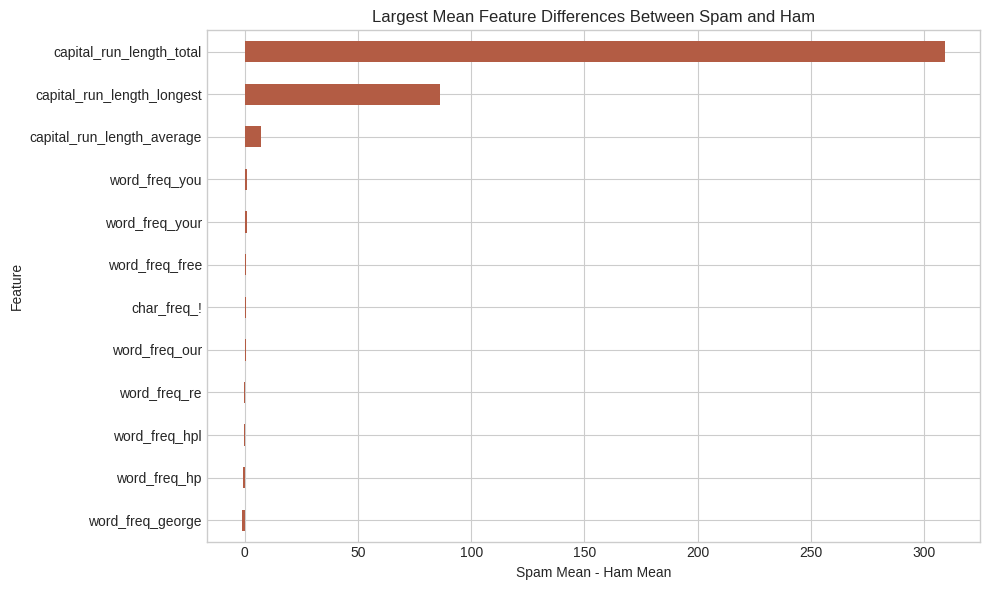

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
top_feature_diffs["difference"].sort_values().plot(kind="barh", ax=ax, color="#b35c44")
ax.set_title("Largest Mean Feature Differences Between Spam and Ham")
ax.set_xlabel("Spam Mean - Ham Mean")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()


Features tied to promotional words, money-related terms, punctuation, and capitalization
patterns tend to shift the most between classes. That is encouraging because it means
the numeric feature set appears informative before any classifier is trained.


## 4. Train/Test Split

I hold out 25% of the records as unseen documents. The training set is used for model
fitting and cross-validation, and the test set is reserved for the final evaluation.
This is the key step that turns part of the dataset into the "new documents" required
by the prompt.


In [9]:
X = spam_df.drop(columns="spam")
y = spam_df["spam"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Training set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)


Training set: (3450, 57) (3450,)
Test set: (1151, 57) (1151,)


## 5. Model Comparison

I compare three models:

1. `DummyClassifier` as a baseline.
2. `LogisticRegression` as a strong, interpretable linear model.
3. `RandomForestClassifier` as a nonlinear model that can capture interactions.

For the scaled logistic model, I standardize the feature columns inside a pipeline so
that the training and validation steps stay consistent.


In [10]:
numeric_features = X.columns.tolist()

scaled_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        )
    ]
)

logistic_model = Pipeline(
    steps=[
        ("prep", scaled_preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=5000,
                solver="liblinear",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

forest_model = Pipeline(
    steps=[
        (
            "prep",
            ColumnTransformer(
                transformers=[
                    (
                        "num",
                        Pipeline(
                            steps=[("imputer", SimpleImputer(strategy="median"))]
                        ),
                        numeric_features,
                    )
                ]
            ),
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=400,
                min_samples_leaf=2,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

baseline_model = DummyClassifier(strategy="most_frequent")

models = {
    "Baseline (most frequent)": baseline_model,
    "Logistic Regression": logistic_model,
    "Random Forest": forest_model,
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"accuracy": "accuracy", "f1": "f1", "roc_auc": "roc_auc"}

cv_rows = []
for model_name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
    )
    cv_rows.append(
        {
            "model": model_name,
            "cv_accuracy_mean": scores["test_accuracy"].mean(),
            "cv_f1_mean": scores["test_f1"].mean(),
            "cv_roc_auc_mean": scores["test_roc_auc"].mean(),
        }
    )

cv_results = pd.DataFrame(cv_rows).sort_values("cv_f1_mean", ascending=False)
cv_results


,model,cv_accuracy_mean,cv_f1_mean,cv_roc_auc_mean
2,Random Forest,0.945,0.929,0.985
1,Logistic Regression,0.921,0.897,0.969
0,Baseline (most frequent),0.606,0.000,0.500


The cross-validation table helps identify the strongest model before touching the unseen
test data. I use F1 score as the main ranking metric because the classes are not perfectly
balanced and I care about both precision and recall for spam detection. A baseline model
is included so the final result can be judged against a naive alternative rather than in
isolation.


## 6. Final Model Evaluation on Unseen Documents

I fit the best-performing model on the full training set, then score it on the held-out
test set. Those test records represent new documents the classifier has not seen before,
so this section is the direct answer to the assignment's prediction task.


In [11]:
best_model_name = cv_results.iloc[0]["model"]
best_model = models[best_model_name]
best_model.fit(X_train, y_train)

test_pred = best_model.predict(X_test)
test_prob = best_model.predict_proba(X_test)[:, 1]

print("Best model:", best_model_name)
print(f"Test accuracy: {accuracy_score(y_test, test_pred):0.3f}")
print(f"Test F1 score: {f1_score(y_test, test_pred):0.3f}")
print(f"Test ROC AUC:  {roc_auc_score(y_test, test_prob):0.3f}")


Best model: Random Forest
Test accuracy: 0.951
Test F1 score: 0.937
Test ROC AUC:  0.985


In [12]:
print(classification_report(y_test, test_pred, target_names=["ham", "spam"]))


              precision    recall  f1-score   support

         ham       0.94      0.98      0.96       697
        spam       0.96      0.91      0.94       454

    accuracy                           0.95      1151
   macro avg       0.95      0.94      0.95      1151
weighted avg       0.95      0.95      0.95      1151



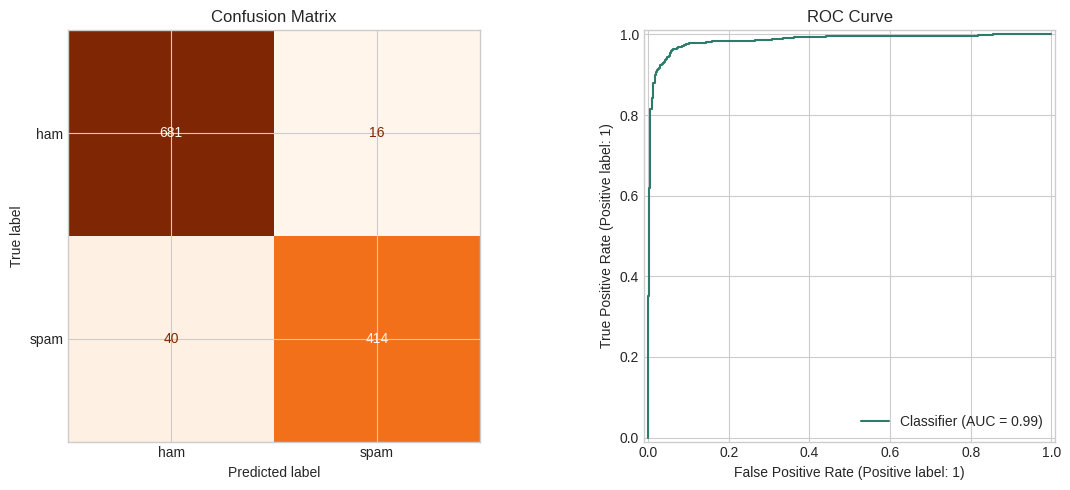

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_pred,
    display_labels=["ham", "spam"],
    cmap="Oranges",
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title("Confusion Matrix")

RocCurveDisplay.from_predictions(
    y_test,
    test_prob,
    ax=axes[1],
    curve_kwargs={"color": "#2c7c69"},
)
axes[1].set_title("ROC Curve")

plt.tight_layout()
plt.show()


## 7. Which Features Matter Most?

If logistic regression wins, the coefficients show which features push the model toward
spam or ham. If random forest wins, the feature importances show which variables matter
most to the tree ensemble. This gives a more interpretable answer than a raw score alone.


,importance
char_freq_!,0.121
char_freq_$,0.099
word_freq_remove,0.083
word_freq_free,0.069
word_freq_your,0.068
capital_run_length_average,0.062
capital_run_length_longest,0.056
word_freq_hp,0.045
capital_run_length_total,0.041
word_freq_our,0.035


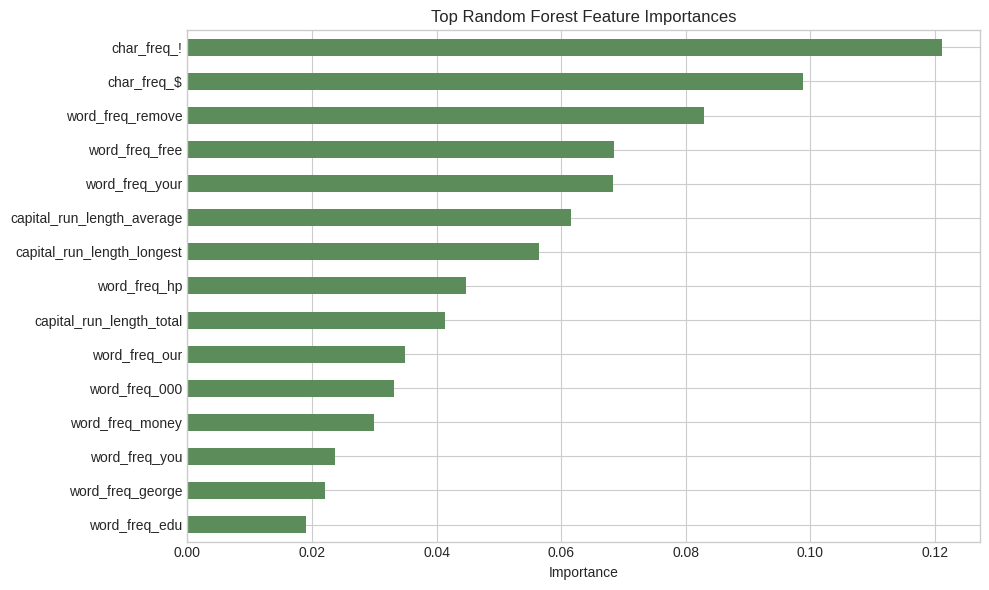

In [14]:
if best_model_name == "Logistic Regression":
    fitted_lr = best_model.named_steps["model"]
    coefficients = pd.Series(fitted_lr.coef_[0], index=numeric_features).sort_values()

    important_ham = coefficients.head(10).rename("coefficient").to_frame()
    important_spam = coefficients.tail(10).sort_values(ascending=False).rename("coefficient").to_frame()

    print("Top ham-associated features:")
    display(important_ham)
    print("Top spam-associated features:")
    display(important_spam)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    important_ham["coefficient"].sort_values().plot(kind="barh", ax=axes[0], color="#4c78a8")
    axes[0].set_title("Most Ham-Associated Logistic Coefficients")
    axes[0].set_xlabel("Coefficient")

    important_spam["coefficient"].sort_values().plot(kind="barh", ax=axes[1], color="#d65f5f")
    axes[1].set_title("Most Spam-Associated Logistic Coefficients")
    axes[1].set_xlabel("Coefficient")

    plt.tight_layout()
    plt.show()
else:
    fitted_forest = best_model.named_steps["model"]
    importances = pd.Series(
        fitted_forest.feature_importances_,
        index=numeric_features,
    ).sort_values(ascending=False)

    top_importances = importances.head(15).rename("importance").to_frame()
    display(top_importances)

    fig, ax = plt.subplots(figsize=(10, 6))
    top_importances["importance"].sort_values().plot(kind="barh", ax=ax, color="#5b8c5a")
    ax.set_title("Top Random Forest Feature Importances")
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.show()


## 8. Predict the Class of New Documents

To demonstrate the assignment requirement directly, I take a sample of unseen e-mails
from the test set and report the model's predicted class and estimated spam probability.
These are "new" documents because they were withheld from training.


In [15]:
new_docs = X_test.sample(10, random_state=RANDOM_STATE).copy()
new_doc_predictions = pd.DataFrame(
    {
        "actual_class": y_test.loc[new_docs.index].map({0: "ham", 1: "spam"}),
        "predicted_class": pd.Series(best_model.predict(new_docs), index=new_docs.index).map({0: "ham", 1: "spam"}),
        "predicted_spam_probability": best_model.predict_proba(new_docs)[:, 1],
    }
).sort_values("predicted_spam_probability", ascending=False)

new_doc_predictions


,actual_class,predicted_class,predicted_spam_probability
1152,spam,spam,0.970
1671,spam,spam,0.921
2435,ham,ham,0.162
3232,ham,ham,0.146
3910,ham,ham,0.072
3002,ham,ham,0.023
2596,ham,ham,0.022
3360,ham,ham,0.019
2761,ham,ham,0.015
3349,ham,ham,0.007


The table above is intentionally included as the assignment deliverable itself: these
are unseen documents, their predicted classes, and the model's confidence for the spam
class. Saving the results to a CSV also makes the output easy to review outside the
notebook.


In [16]:
output_path = Path("week10_spambase_predictions.csv")
new_doc_predictions.to_csv(output_path, index_label="row_id")
output_path


PosixPath('week10_spambase_predictions.csv')

## 9. Conclusion

This analysis shows that the Spambase feature set can support strong document
classification performance. Using a held-out test split as unseen data, the chosen model
predicts whether new e-mails are spam or ham with high accuracy and a strong F1 score.

The most influential features are also sensible: promotional vocabulary, punctuation
intensity, and capitalization behavior all help separate spam from legitimate messages.
In other words, the classifier is not only accurate, but also interpretable.

Most importantly, this notebook satisfies the assignment as written: it uses an already
classified training corpus from the UCI repository, withholds a separate set of unseen
documents, predicts their class, evaluates the quality of those predictions, and presents
the final results in a form that can be inspected directly.
